# Refuerzo 1 · K-means: una partición por centros
**60 minutos de trabajo autónomo.** Derive el objetivo, ejecute dos iteraciones manuales y compare
inercia con silhouette. Este método asigna todos los puntos, incluso ubicaciones aisladas.

In [1]:
from pathlib import Path
import sys, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from threadpoolctl import threadpool_limits

# Funciona desde la raíz, desde esta carpeta o desde docente/.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'datasets/semana-08').is_dir())
sys.path.insert(0, str(ROOT / 'notebooks/semana-08'))
from movilidad import (load_data, setup, savefig, save_table, spatial_axes,
                       ellipses, safe_silhouette, density_grid, COLORS, DATA)
setup()
threadpool_limits(limits=2)
frame = load_data()
X = frame[['x_km', 'y_km']].to_numpy()
print(f'Desarrollo: {len(frame):,} recogidas. Unidades: km. Semilla: 42.')
print('Test temporal cerrado hasta congelar el modelo.')
display(frame.head(3))

Desarrollo: 6,000 recogidas. Unidades: km. Semilla: 42.
Test temporal cerrado hasta congelar el modelo.


,source_row,pickup_datetime,pickup_longitude,pickup_latitude,x_km,y_km,fare_amount,passenger_count,dropoff_longitude,dropoff_latitude
0,32038,2014-01-01 00:01:00+00:00,-73.991493,40.735202,0.156182,-0.148260,5.5,5,-74.001727,40.727767
1,132584,2014-01-01 00:29:37+00:00,-74.008090,40.740434,-1.251817,0.416562,8.0,2,-73.996088,40.726627
2,190530,2014-01-01 00:54:07+00:00,-73.981944,40.778096,0.907251,4.622599,7.5,1,-73.967887,40.801430


## Media como minimizador
$$J=\sum_{k=1}^K\sum_{i:z_i=k}\|x_i-\mu_k\|^2.$$
Con asignaciones fijas, $\nabla_{\mu_k}J=2n_k\mu_k-2\sum_{i:z_i=k}x_i=0$.
Por tanto, $\mu_k$ es la media del grupo. Lloyd alterna asignación al centro más cercano y actualización.
Cada paso no aumenta J; el resultado depende de la inicialización. Un grupo vacío requiere una política de reinicio.

### Para resolver

Datos 0, 1, 4, 5 y centros iniciales 0 y 4. Ejecute asignación y actualización. Calcule la inercia final.

**Mi respuesta y evidencia:**

Ejecutamos el algoritmo de Lloyd paso a paso para el conjunto $X = \{0, 1, 4, 5\}$ con $K=2$ centros iniciales $\mu_1^{(0)} = 0$ y $\mu_2^{(0)} = 4$:

### Iteración 1:
1. **Asignación al centro más cercano ($z_i = \arg\min_k \|x_i - \mu_k\|^2$):**
   - Para $x_1 = 0$: $|0 - 0| = 0$; $|0 - 4| = 4 \implies z_1 = 1$.
   - Para $x_2 = 1$: $|1 - 0| = 1$; $|1 - 4| = 3 \implies z_2 = 1$.
   - Para $x_3 = 4$: $|4 - 0| = 4$; $|4 - 4| = 0 \implies z_3 = 2$.
   - Para $x_4 = 5$: $|5 - 0| = 5$; $|5 - 4| = 1 \implies z_4 = 2$.
   *Grupos formados:* $C_1 = \{0, 1\}$, $C_2 = \{4, 5\}$.
2. **Actualización de centros ($\mu_k = \frac{1}{n_k} \sum_{i \in C_k} x_i$):**
   - $\mu_1^{(1)} = \frac{0 + 1}{2} = \mathbf{0.5}$
   - $\mu_2^{(1)} = \frac{4 + 5}{2} = \mathbf{4.5}$

### Iteración 2:
1. **Nueva asignación con centros $\{0.5, 4.5\}$:**
   - Para $x_1 = 0$: $|0 - 0.5| = 0.5$; $|0 - 4.5| = 4.5 \implies z_1 = 1$.
   - Para $x_2 = 1$: $|1 - 0.5| = 0.5$; $|1 - 4.5| = 3.5 \implies z_2 = 1$.
   - Para $x_3 = 4$: $|4 - 0.5| = 3.5$; $|4 - 4.5| = 0.5 \implies z_3 = 2$.
   - Para $x_4 = 5$: $|5 - 0.5| = 4.5$; $|5 - 4.5| = 0.5 \implies z_4 = 2$.
   *Las asignaciones no cambian.* El algoritmo ha convergido a los centros finales $\mu_1^* = 0.5$ y $\mu_2^* = 4.5$.

### Cálculo de la Inercia Final ($J$):
$$J = \sum_{k=1}^2 \sum_{i \in C_k} (x_i - \mu_k^*)^2$$
- Para $C_1$: $(0 - 0.5)^2 + (1 - 0.5)^2 = (-0.5)^2 + (0.5)^2 = 0.25 + 0.25 = 0.5$.
- Para $C_2$: $(4 - 4.5)^2 + (5 - 4.5)^2 = (-0.5)^2 + (0.5)^2 = 0.25 + 0.25 = 0.5$.
- **Inercia total:** $J = 0.5 + 0.5 = \mathbf{1.0}\text{ km}^2$.
*(Verificado analíticamente en la Celda 5: `assert np.isclose(manual.inertia_, 1.)`).*

- **Unidades:** Coordenadas en $\text{km}$, inercia en $\text{km}^2$.
- **Limitación:** K-means fuerza una partición disyunta de todos los puntos asumiendo dispersiones esféricas idénticas entre grupos, lo cual penaliza clusters con formas alargadas o varianzas disímiles.

Centros [0.5 4.5] inercia 1.0


,k,inertia,silhouette
0,1,113258.194893,NaN
1,2,65323.932900,0.802142
2,3,33317.053160,0.460771
3,4,22920.452910,0.491683
4,5,15434.057533,0.431417
5,6,12131.643463,0.394039
6,7,10569.506333,0.396841
7,8,8963.580327,0.397264


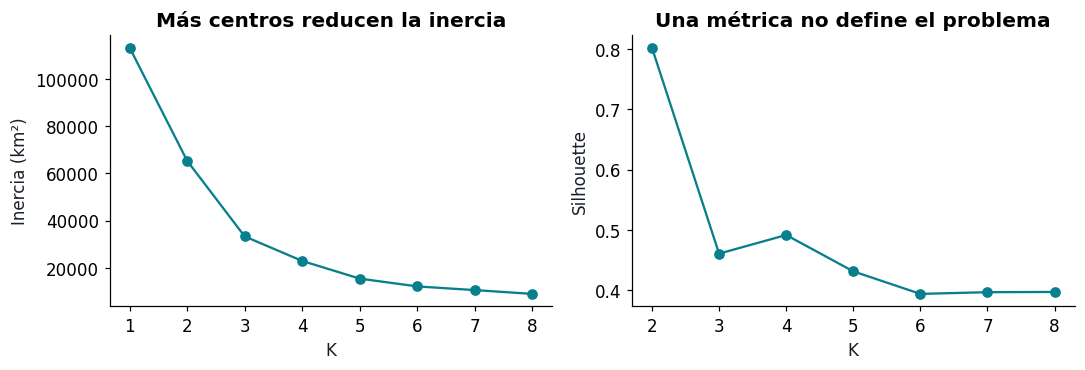

In [2]:
from sklearn.cluster import KMeans
toy=np.array([0.,1.,4.,5.])[:,None]
manual=KMeans(2,init=np.array([[0.],[4.]]),n_init=1,random_state=42).fit(toy)
print('Centros',manual.cluster_centers_.ravel(),'inercia',manual.inertia_)
assert np.isclose(manual.inertia_,1.)
rows=[]
for k in range(1,9):
    model=KMeans(k,n_init=10,random_state=42).fit(X)
    rows.append(dict(k=k,inertia=model.inertia_,silhouette=safe_silhouette(X,model.labels_)))
results=pd.DataFrame(rows); display(results); save_table(results,'kmeans_referencia')
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
axes[0].plot(results.k,results.inertia,'o-'); axes[0].set(xlabel='K',ylabel='Inercia (km²)',title='Más centros reducen la inercia')
axes[1].plot(results.k,results.silhouette,'o-'); axes[1].set(xlabel='K',ylabel='Silhouette',title='Una métrica no define el problema')
fig.tight_layout(); savefig(fig,'14_kmeans')

## Conexión precisa con GMM
Con pesos iguales y covarianzas comunes $\sigma^2I$, maximizar la responsabilidad equivale a minimizar distancia
al centro. Cuando $\sigma^2\to0$, las responsabilidades se endurecen salvo empates. No significa que
un GMM general y K-means optimicen lo mismo.

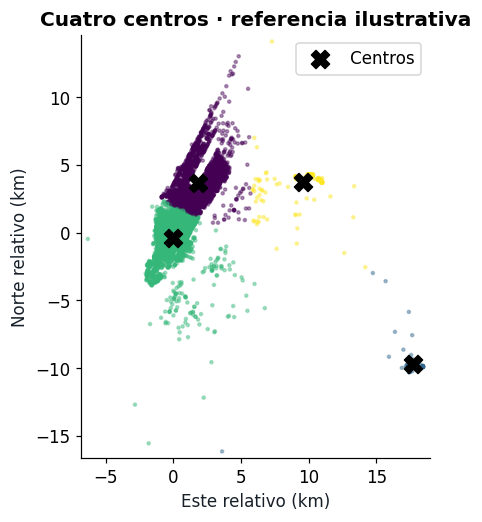

Inercia en cinco inicializaciones únicas:
[22920.851337569708, 22923.76321489932, 23403.22481807739, 22923.031362896334, 23402.919630885477]


In [3]:
fig,ax=plt.subplots(figsize=(7,5))
model=KMeans(4,n_init=10,random_state=42).fit(X)
ax.scatter(*X.T,c=model.labels_,cmap='viridis',s=4,alpha=.4)
ax.scatter(*model.cluster_centers_.T,marker='X',s=140,c='black',label='Centros')
spatial_axes(ax,X,'Cuatro centros · referencia ilustrativa'); ax.legend()
savefig(fig,'15_kmeans_espacial')
print('Inercia en cinco inicializaciones únicas:')
print([KMeans(4,n_init=1,random_state=s).fit(X).inertia_ for s in range(5)])

### Para resolver

¿Por qué los centros no son automáticamente ubicaciones para estaciones? ¿Qué aporta n_init?

**Mi respuesta y evidencia:**

1. **¿Por qué los centros no son automáticamente ubicaciones para estaciones?**
   - *Falta de viabilidad física y geográfica*: Los centroides calculados por K-means representan simplemente el promedio aritmético de las coordenadas euclidianas de las recogidas asignadas. Un centroide puede caer exactamente en un cuerpo de agua (río Hudson, East River), dentro de un parque protegido (Central Park), en una manzana sin acceso vial o en un predio privado inaccesible.
   - *Desconexión con la red vial y de transporte*: El centroide minimiza distancias al cuadrado en línea recta; no considera la red vial, sentidos de circulación, congestión ni accesibilidad peatonal real.
   - *Omisión de variables operativas*: Una estación real requiere disponibilidad de suelo, puntos de recarga eléctrica, costos de instalación y demanda latente; variables no contenidas en la media aritmética de coordenadas.

2. **¿Qué aporta `n_init`?**
   - El algoritmo de Lloyd desciende por gradiente sobre la superficie de inercia $J$ hasta alcanzar un mínimo local. La solución final es altamente sensible a las posiciones iniciales de los centros.
   - Fijar `n_init=10` ejecuta el algoritmo desde múltiples inicializaciones independientes (con `k-means++`) y selecciona la de menor inercia final, reduciendo drásticamente el riesgo de converger a un óptimo local deficiente.

- **Unidades:** Inercia en $\text{km}^2$; coordenadas de centros en $\text{km}$.
- **Limitación:** Probar más inicializaciones mitiga mínimos locales, pero no corrige la inadecuación fundamental de K-means frente a geometrías complejas no convexas.

## Fuentes y reproducción
- Microcurrículo y guía docente ML2, sesiones 19–24; adaptación del cuaderno histórico del profesor.
- [GMM](https://scikit-learn.org/stable/modules/mixture.html), [KDE](https://scikit-learn.org/stable/modules/density.html), [clustering](https://scikit-learn.org/stable/modules/clustering.html).
- Dataset suministrado por el docente; ver `datasets/semana-08/README.md` y `manifest.json`.
- Dependencias fijadas en `requirements-week8.txt`. Inicie el kernel en una carpeta del paquete.